# **4.  Develop an LSTM-based model for time-series forecasting using stock price, weather, or sales datasets.**


In [13]:
#Import Libraries and Download Dataset
import kagglehub
from kagglehub import KaggleDatasetAdapter

import tensorflow as tf
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

path = kagglehub.dataset_download("rohitsahoo/sales-forecasting")

print("Dataset path:", path)

Using Colab cache for faster access to the 'sales-forecasting' dataset.
Dataset path: /kaggle/input/sales-forecasting


In [14]:
#Load and Inspect Dataset
print('Contents of the dataset directory:')
for item in os.listdir(path):
    print(item)


Contents of the dataset directory:
train.csv


In [15]:
data_file_path = os.path.join(path, "train.csv")
df = pd.read_csv(data_file_path)
print("First 5 records:")
print(df.head())

First 5 records:
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688  12/06/2017  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   

   Postal Code Region       Produ

In [18]:
#Convert Date to Date-Time Format
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)

print(df[['Order Date', 'Sales']].head())
print(df['Order Date'].dtype)

  Order Date     Sales
0 2017-11-08  261.9600
1 2017-11-08  731.9400
2 2017-06-12   14.6200
3 2016-10-11  957.5775
4 2016-10-11   22.3680
datetime64[ns]


In [22]:
#Aggregate Sales by Month
monthly_sales = (
    df.groupby(
        pd.Grouper(
            key='Order Date',
            freq='ME'
        )
    )['Sales']
    .sum()
    .reset_index()
)

print(monthly_sales.head(10))

  Order Date       Sales
0 2015-01-31  14205.7070
1 2015-02-28   4519.8920
2 2015-03-31  55205.7970
3 2015-04-30  27906.8550
4 2015-05-31  23644.3030
5 2015-06-30  34322.9356
6 2015-07-31  33781.5430
7 2015-08-31  27117.5365
8 2015-09-30  81623.5268
9 2015-10-31  31453.3930


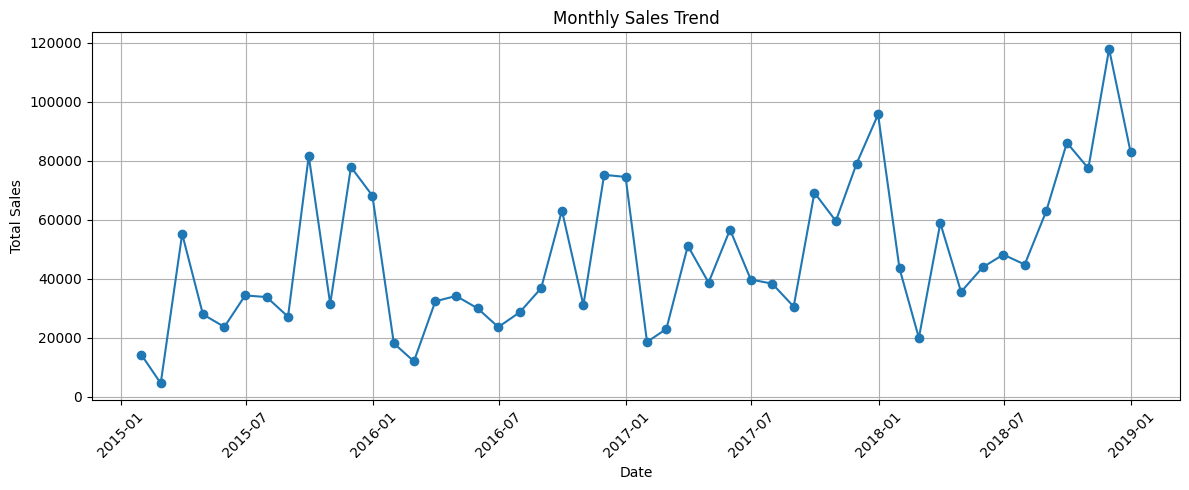

In [21]:
#Visualize Monthly Sales Trend
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales['Order Date'],
    monthly_sales['Sales'],
    marker='o'
)

plt.title('Monthly Sales Trend')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

In [24]:
#Split Data into Training and Testing Sets
train_size = int(len(sales) * 0.8)

train_data = sales[:train_size]
test_data = sales[train_size:]

print("Training data:", len(train_data))
print("Testing data:", len(test_data))

Training data: 38
Testing data: 10


In [25]:
#Normalize Sales Data
scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(
    train_data.reshape(-1, 1)
)

test_scaled = scaler.transform(
    test_data.reshape(-1, 1)
)

print("Original first value:", train_data[0])
print("Scaled first value:", train_scaled[0])

Original first value: 14205.707
Scaled first value: [0.10618172]


In [29]:
#Create LSTM Time-Series Sequences
def create_sequences(data, time_steps=12):
    X = []
    y = []

    for i in range(len(data) - time_steps):
        X.append(data[i:i + time_steps])
        y.append(data[i + time_steps])

    return np.array(X), np.array(y)


X_train, y_train = create_sequences(
    train_scaled,
    time_steps=12
)

test_input = np.concatenate(
    [train_scaled[-12:], test_scaled]
)

X_test, y_test = create_sequences(
    test_input,
    time_steps=12
)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (26, 12, 1)
y_train shape: (26, 1)
X_test shape: (10, 12, 1)
y_test shape: (10, 1)


In [28]:
#Build LSTM Model
model = tf.keras.Sequential([

    tf.keras.layers.Input(shape=(12, 1)),

    tf.keras.layers.LSTM(64),

    tf.keras.layers.Dense(32, activation='relu'),

    tf.keras.layers.Dense(1)
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,009 (74.25 KB)

 Trainable params: 19,009 (74.25 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
#Train the LSTM Model
model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=4,
    validation_split=0.2
)

Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 250ms/step - loss: 0.1355 - val_loss: 0.3029
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0730 - val_loss: 0.1873
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.0414 - val_loss: 0.1068
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0446 - val_loss: 0.0975
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0438 - val_loss: 0.1096
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0411 - val_loss: 0.1299
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0410 - val_loss: 0.1412
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0412 - val_loss: 0.1363
Epoch 9/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0401 - val_loss: 0.1304
Epoch 10/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0397 - val_loss: 0.1250
Epoch 11/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0401 - val_loss: 0.1143
Epoch 12/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0403 - val_loss: 0.1207


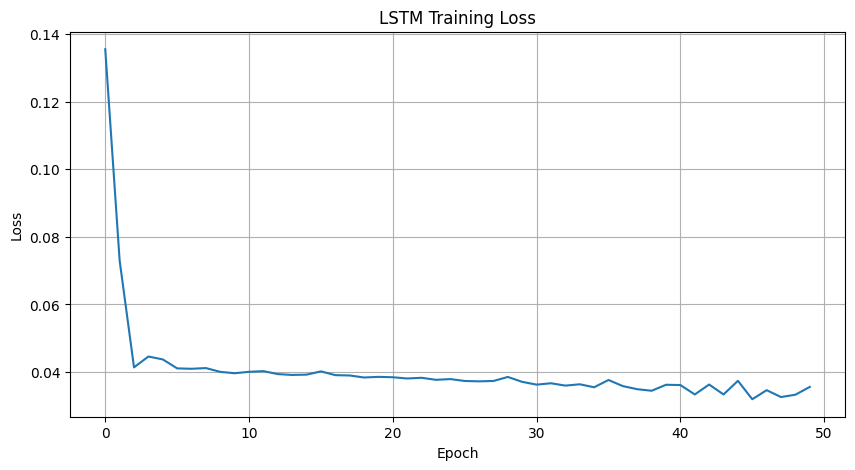

In [32]:
#Visualize Training Loss
plt.figure(figsize=(10, 5))

plt.plot(history.history['loss'])

plt.title('LSTM Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.grid(True)
plt.show()

In [33]:
#Generate Predictions
predictions = model.predict(X_test)

predictions = scaler.inverse_transform(predictions)
actual = scaler.inverse_transform(y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step


In [34]:
#Evaluate Model Using RMSE
rmse = np.sqrt(
    mean_squared_error(actual, predictions)
)

print("RMSE:", rmse)

RMSE: 30510.77268393601


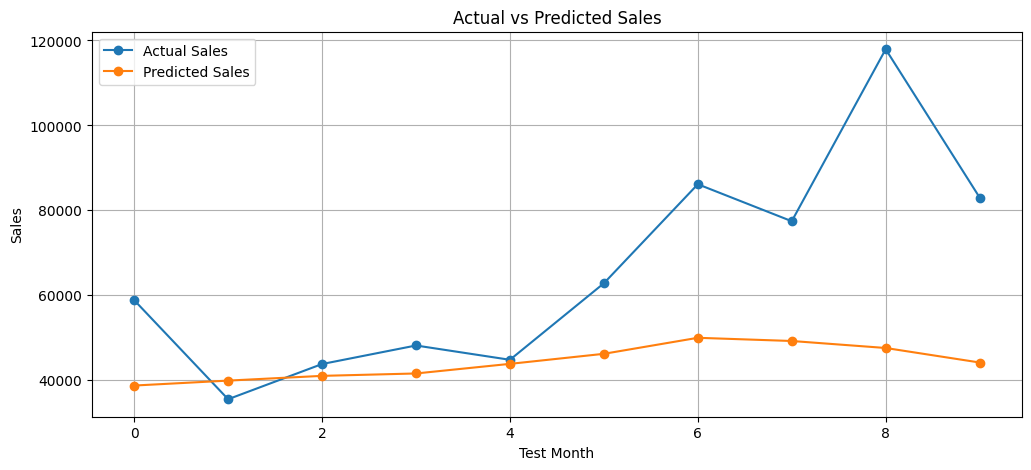

In [35]:
#Compare Actual and Predicted Sales
plt.figure(figsize=(12, 5))

plt.plot(actual, label='Actual Sales', marker='o')
plt.plot(predictions, label='Predicted Sales', marker='o')

plt.title('Actual vs Predicted Sales')
plt.xlabel('Test Month')
plt.ylabel('Sales')

plt.legend()
plt.grid(True)
plt.show()